# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Global Coffee Sales Shop Dataset](https://www.kaggle.com/datasets/moezalikhan/global-coffee-shop-sales-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

/kaggle/input/datasets/moezalikhan/global-coffee-shop-sales-dataset/coffee_shop_sales.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('coffee_shop_sales.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
0,10001,2023-01-01 00:39:39,35,Melbourne,AUS,Mall Kiosk,Coffee,Double Espresso,3.04,1,True,Credit Card,qiyfrwsk,35-44,Female,False,Sunny,22.2,New Year's Day,2.74
1,10002,2023-01-01 01:06:53,25,Manchester,UK,Standalone,Coffee,Single Espresso,2.38,2,False,Debit Card,vf0jqqnv,18-24,Male,False,Sunny,8.7,New Year's Day,4.76
2,10003,2023-01-01 02:56:18,23,Manchester,UK,Standalone,Tea,Large Matcha Latte,4.26,2,False,Mobile Wallet,fcd6mzsg,25-34,Male,False,Sunny,8.7,New Year's Day,8.52
3,10004,2023-01-01 02:58:30,38,Toronto,CAN,Standalone,Coffee,Medium Cappuccino,3.68,2,False,Credit Card,jvu2cgxu,55-64,Female,True,Cloudy,-6.5,New Year's Day,7.36
4,10005,2023-01-01 03:13:53,9,Los Angeles,USA,Mall Kiosk,Coffee,Small Cappuccino,3.42,1,False,Mobile Wallet,po4ljedg,18-24,Male,True,Sunny,12.3,New Year's Day,3.42


## last Five row

In [4]:
df.tail()

,transaction_id,timestamp,store_id,city,country,store_type,product_category,product_name,unit_price,quantity,discount_applied,payment_method,customer_id,customer_age_group,customer_gender,loyalty_member,weather_condition,temperature_c,holiday_name,total_amount
19995,29996,2023-12-31 19:33:40,43,Vancouver,CAN,Standalone,Tea,Medium Chai Latte,3.95,1,True,Credit Card,ulmouymi,45-54,Male,False,Rainy,5.1,NaN,3.75
19996,29997,2023-12-31 19:34:58,24,Manchester,UK,Standalone,Coffee,Double Espresso,2.38,2,False,Mobile Wallet,xaj2t3z1,18-24,Male,True,Sunny,6.0,NaN,4.76
19997,29998,2023-12-31 19:37:34,13,Chicago,USA,Mall Kiosk,Sandwich,Chicken & Avocado Wrap,5.99,1,False,Cash,t2cfzn28,65+,Female,True,Sunny,-3.1,NaN,5.99
19998,29999,2023-12-31 19:53:35,16,London,UK,Standalone,Coffee,Large Mocha,4.42,1,False,Credit Card,u2tl08at,25-34,Female,False,Cloudy,7.0,NaN,4.42
19999,30000,2023-12-31 22:54:02,42,Vancouver,CAN,Standalone,Pastry,Scone,2.07,1,False,Cash,feq8sejr,55-64,Female,True,Rainy,5.1,NaN,2.07


## Shape of our dataset

In [5]:
df.shape

(20000, 20)

## List out all columns

In [6]:
df.columns

Index(['transaction_id', 'timestamp', 'store_id', 'city', 'country',
       'store_type', 'product_category', 'product_name', 'unit_price',
       'quantity', 'discount_applied', 'payment_method', 'customer_id',
       'customer_age_group', 'customer_gender', 'loyalty_member',
       'weather_condition', 'temperature_c', 'holiday_name', 'total_amount'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

transaction_id          int64
timestamp              object
store_id                int64
city                   object
country                object
store_type             object
product_category       object
product_name           object
unit_price            float64
quantity                int64
discount_applied         bool
payment_method         object
customer_id            object
customer_age_group     object
customer_gender        object
loyalty_member           bool
weather_condition      object
temperature_c         float64
holiday_name           object
total_amount          float64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   transaction_id      20000 non-null  int64  
 1   timestamp           20000 non-null  object 
 2   store_id            20000 non-null  int64  
 3   city                20000 non-null  object 
 4   country             20000 non-null  object 
 5   store_type          20000 non-null  object 
 6   product_category    20000 non-null  object 
 7   product_name        20000 non-null  object 
 8   unit_price          20000 non-null  float64
 9   quantity            20000 non-null  int64  
 10  discount_applied    20000 non-null  bool   
 11  payment_method      20000 non-null  object 
 12  customer_id         20000 non-null  object 
 13  customer_age_group  18924 non-null  object 
 14  customer_gender     18928 non-null  object 
 15  loyalty_member      20000 non-null  bool   
 16  weat

## Check Null Value

In [9]:
df.isnull().sum()

transaction_id            0
timestamp                 0
store_id                  0
city                      0
country                   0
store_type                0
product_category          0
product_name              0
unit_price                0
quantity                  0
discount_applied          0
payment_method            0
customer_id               0
customer_age_group     1076
customer_gender        1072
loyalty_member            0
weather_condition       978
temperature_c           978
holiday_name          19665
total_amount              0
dtype: int64

## drop unwanted columns

In [10]:
df = df.drop(columns=['holiday_name', 'transaction_id', 'customer_id'])

## convert timestamp into useful features

In [11]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

## drop original timestamp

In [12]:
df = df.drop(columns=['timestamp'])

## separate numerical & categorical columns

In [13]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object', 'bool']).columns

## fill numerical nulls with mean

In [14]:
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

## fill categorical nulls with mode

In [15]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

## final check

In [16]:
print(df.isnull().sum().sum())

0


## Check Dupicate Value

In [17]:
df.duplicated().sum()

np.int64(0)

## Summary

In [18]:
df.describe()

,store_id,unit_price,quantity,temperature_c,total_amount,hour,day,month
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,23.072950,4.049521,1.71265,13.556550,6.850464,11.159150,15.636600,6.540250
std,13.097332,1.982984,1.10808,7.982242,5.989221,4.691186,8.852969,3.478475
min,1.000000,1.640000,1.00000,-11.000000,1.310000,0.000000,1.000000,1.000000
25%,12.000000,2.820000,1.00000,8.000000,3.360000,8.000000,8.000000,4.000000
50%,23.000000,3.690000,1.00000,14.000000,4.920000,11.000000,16.000000,7.000000
75%,34.000000,4.750000,2.00000,19.500000,8.200000,15.000000,23.000000,10.000000
max,45.000000,18.750000,9.00000,32.600000,112.000000,23.000000,31.000000,12.000000


# EDA

In [19]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

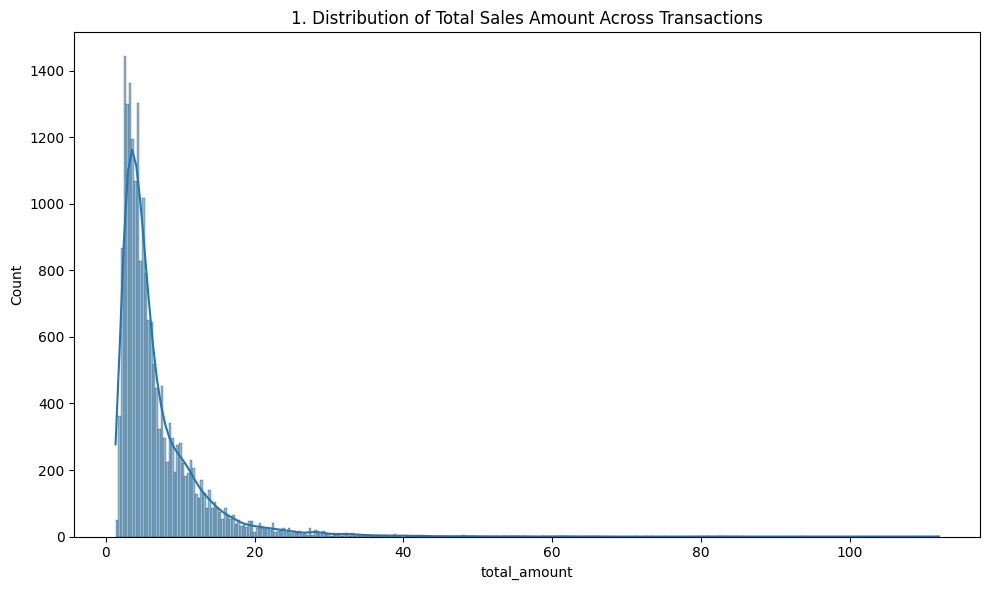

In [20]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['total_amount'], kde=True)
plt.title(f'{plot_no}. Distribution of Total Sales Amount Across Transactions')
show_fig()
plot_no += 1

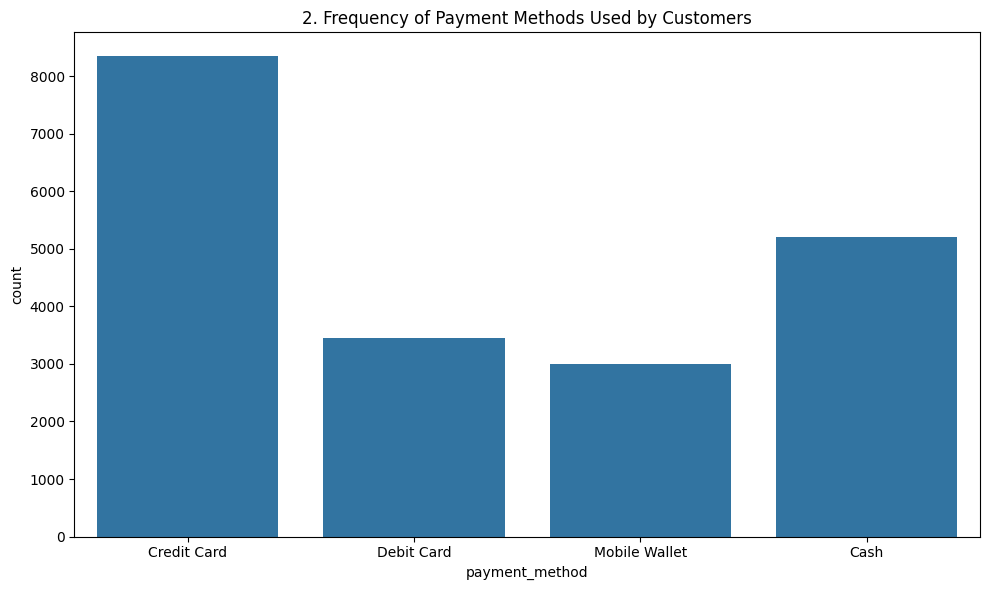

In [21]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='payment_method', data=df)
plt.title(f'{plot_no}. Frequency of Payment Methods Used by Customers')
show_fig()
plot_no += 1

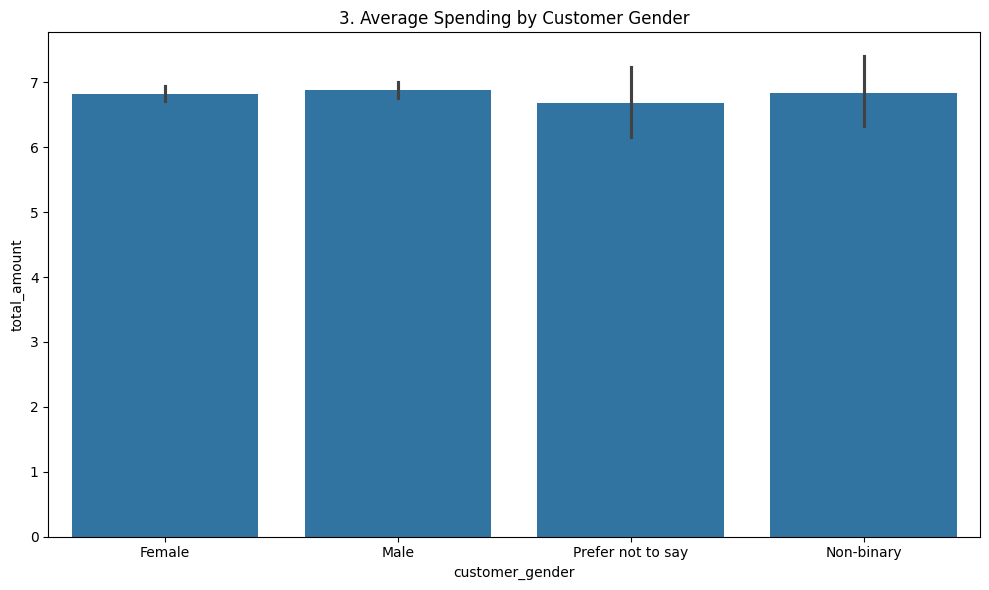

In [22]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='customer_gender', y='total_amount', data=df)
plt.title(f'{plot_no}. Average Spending by Customer Gender')
show_fig()
plot_no += 1

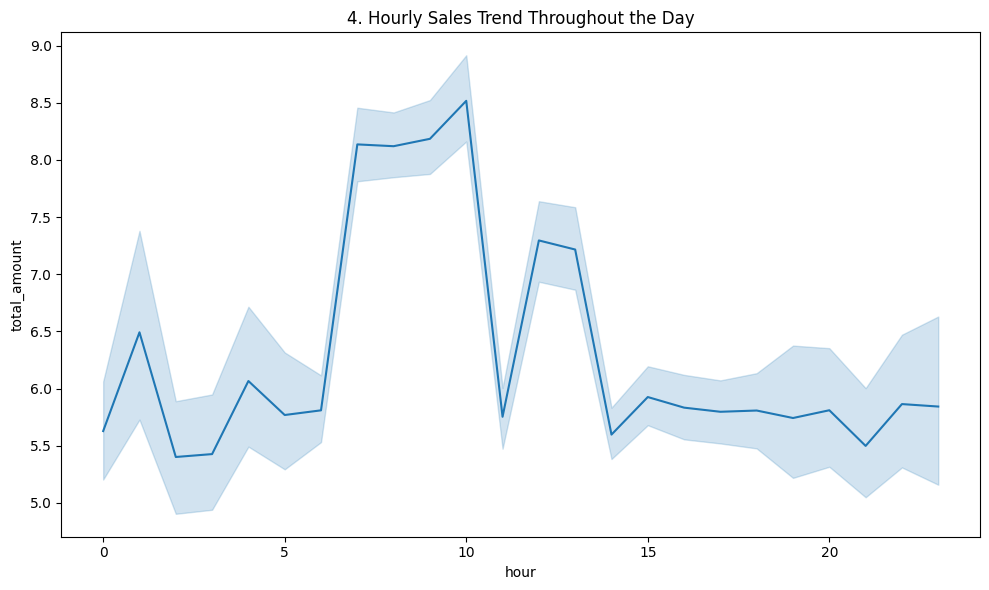

In [23]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='hour', y='total_amount', data=df)
plt.title(f'{plot_no}. Hourly Sales Trend Throughout the Day')
show_fig()
plot_no += 1

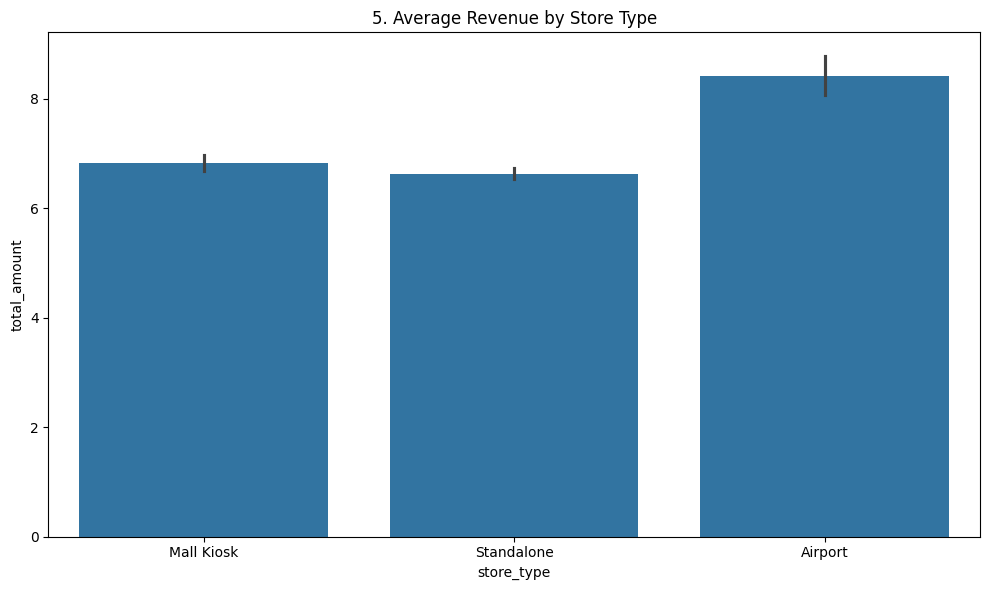

In [24]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='store_type', y='total_amount', data=df)
plt.title(f'{plot_no}. Average Revenue by Store Type')
show_fig()
plot_no += 1

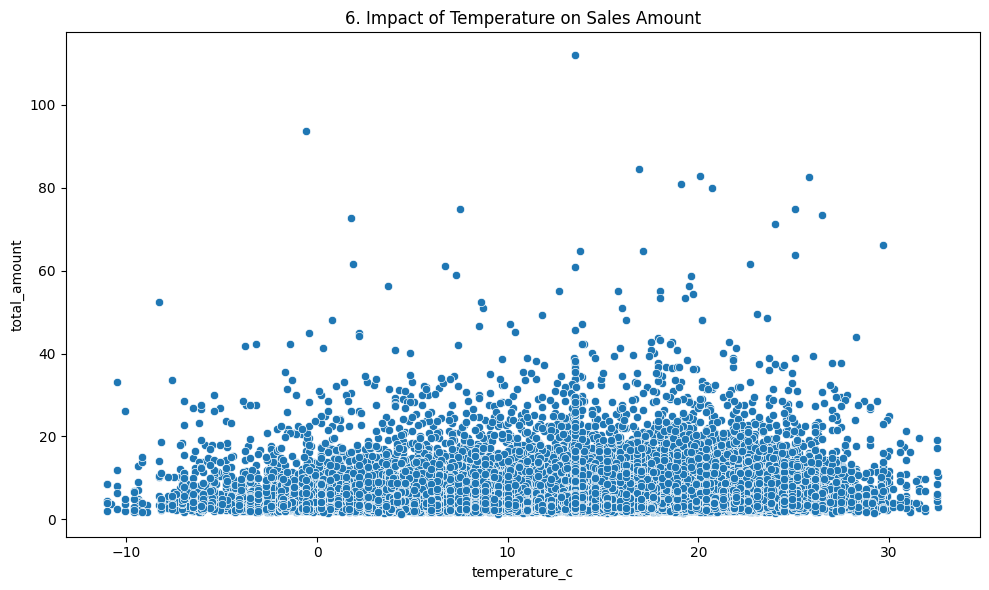

In [25]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='temperature_c', y='total_amount', data=df)
plt.title(f'{plot_no}. Impact of Temperature on Sales Amount')
show_fig()
plot_no += 1

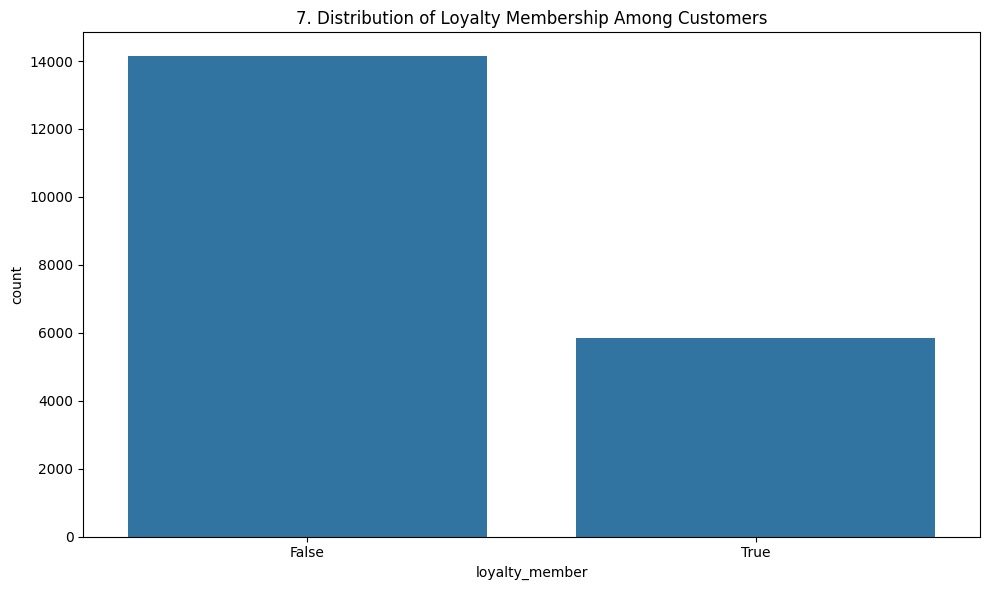

In [26]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='loyalty_member', data=df)
plt.title(f'{plot_no}. Distribution of Loyalty Membership Among Customers')
show_fig()
plot_no += 1

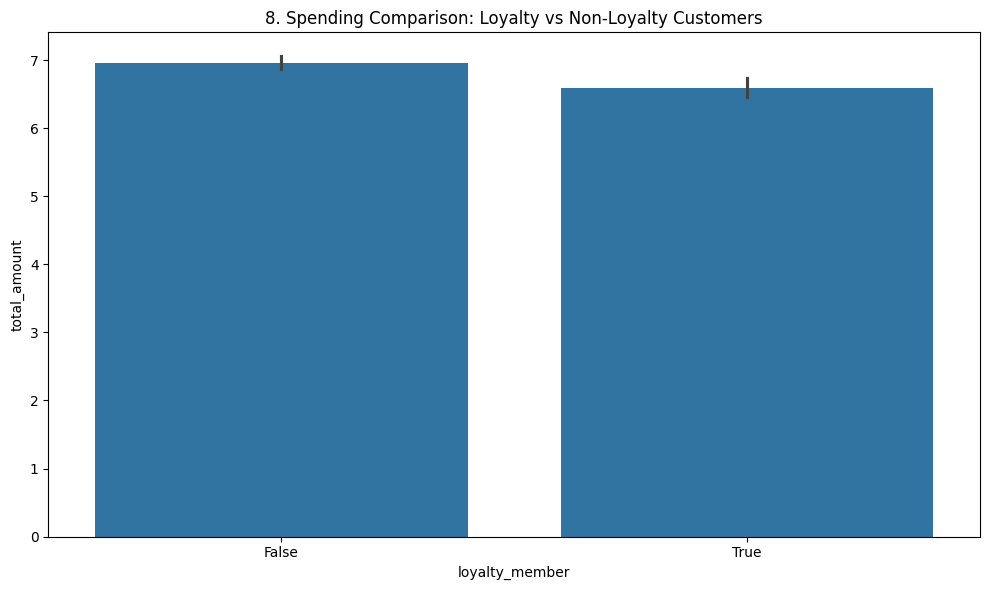

In [27]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='loyalty_member', y='total_amount', data=df)
plt.title(f'{plot_no}. Spending Comparison: Loyalty vs Non-Loyalty Customers')
show_fig()
plot_no += 1

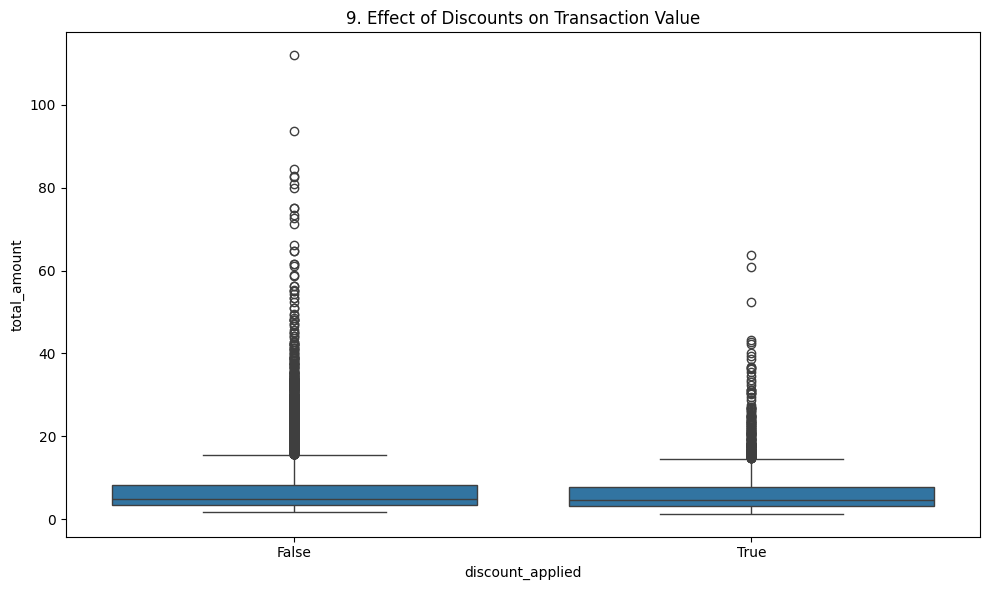

In [28]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(x='discount_applied', y='total_amount', data=df)
plt.title(f'{plot_no}. Effect of Discounts on Transaction Value')
show_fig()
plot_no += 1

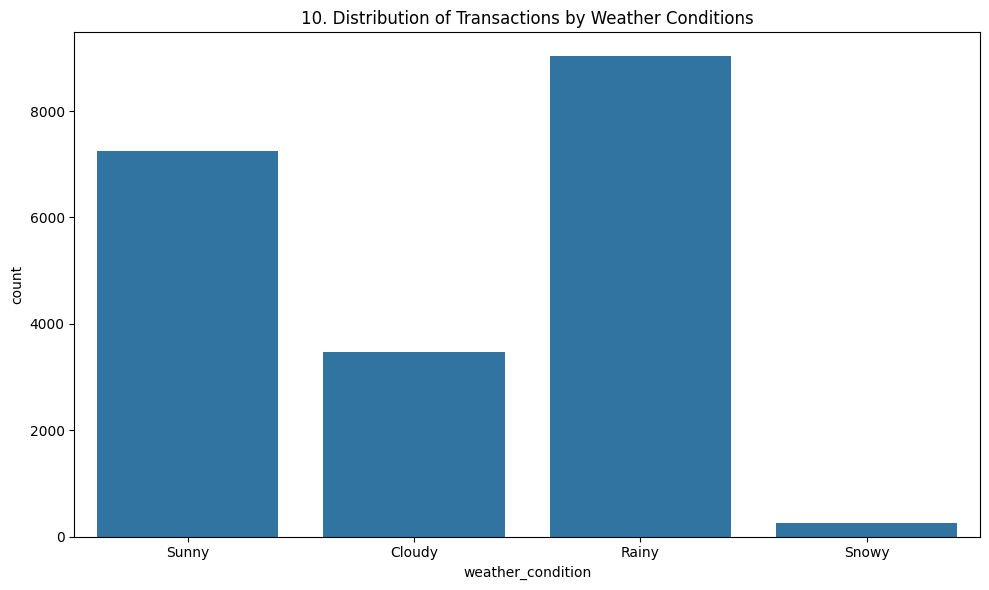

In [29]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='weather_condition', data=df)
plt.title(f'{plot_no}. Distribution of Transactions by Weather Conditions')
show_fig()
plot_no += 1

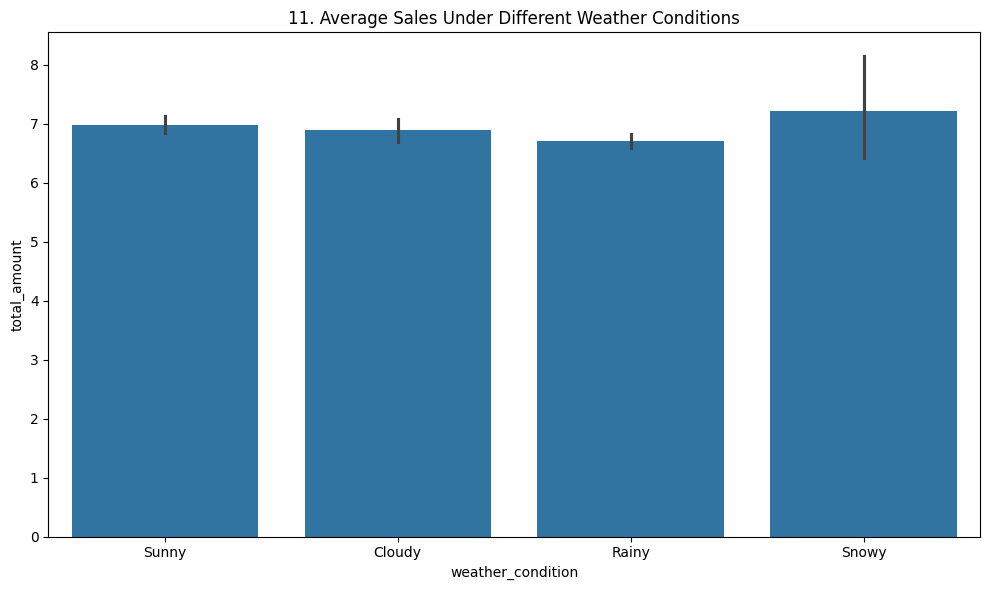

In [30]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='weather_condition', y='total_amount', data=df)
plt.title(f'{plot_no}. Average Sales Under Different Weather Conditions')
show_fig()
plot_no += 1

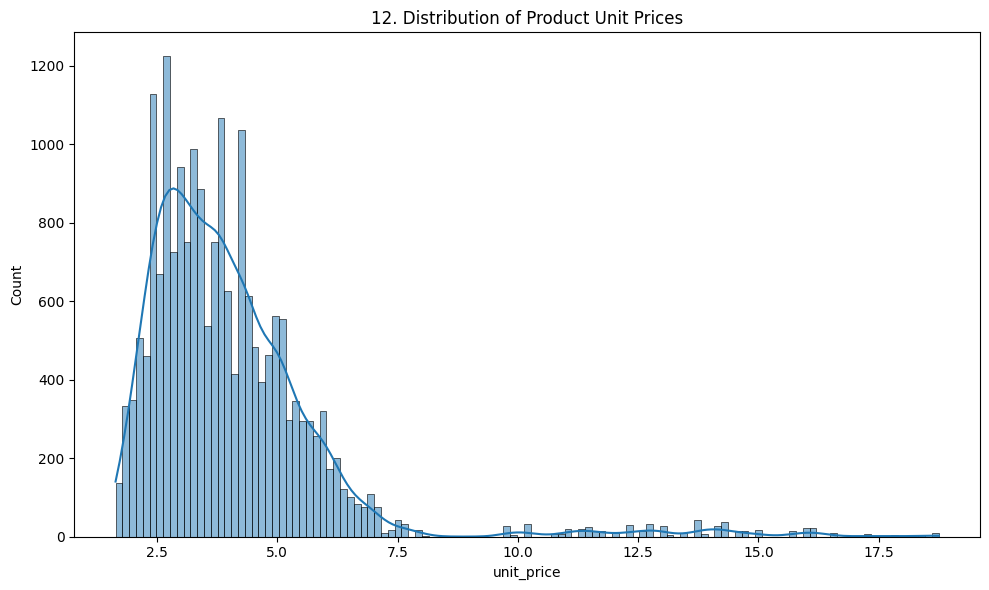

In [31]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['unit_price'], kde=True)
plt.title(f'{plot_no}. Distribution of Product Unit Prices')
show_fig()
plot_no += 1

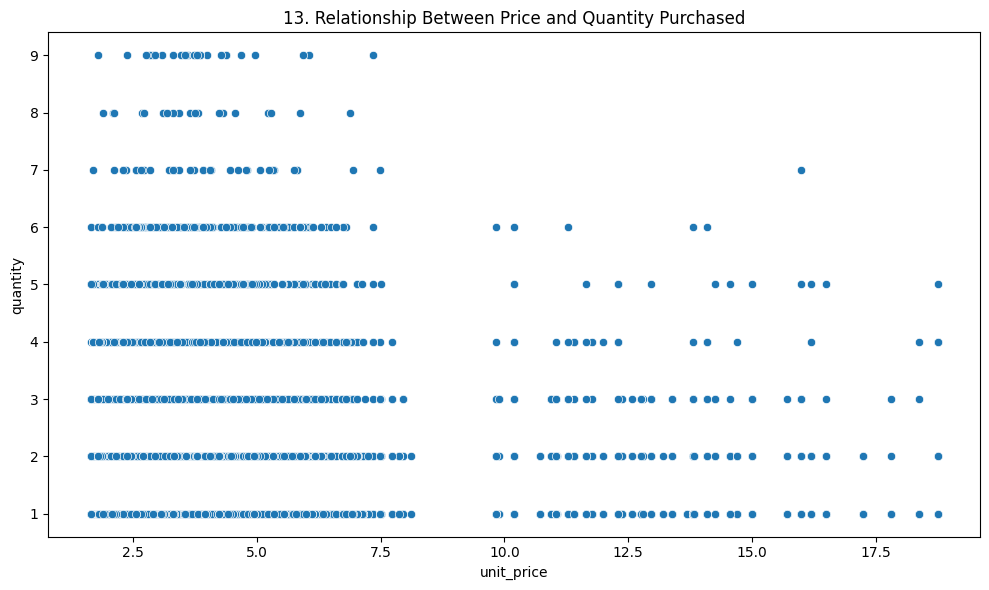

In [32]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='unit_price', y='quantity', data=df)
plt.title(f'{plot_no}. Relationship Between Price and Quantity Purchased')
show_fig()
plot_no += 1

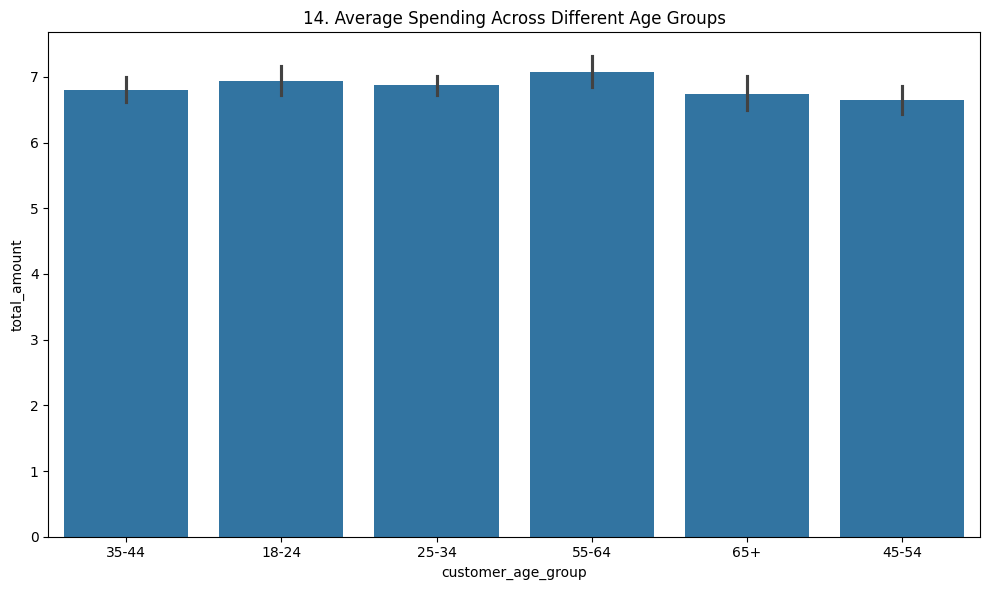

In [33]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='customer_age_group', y='total_amount', data=df)
plt.title(f'{plot_no}. Average Spending Across Different Age Groups')
show_fig()
plot_no += 1

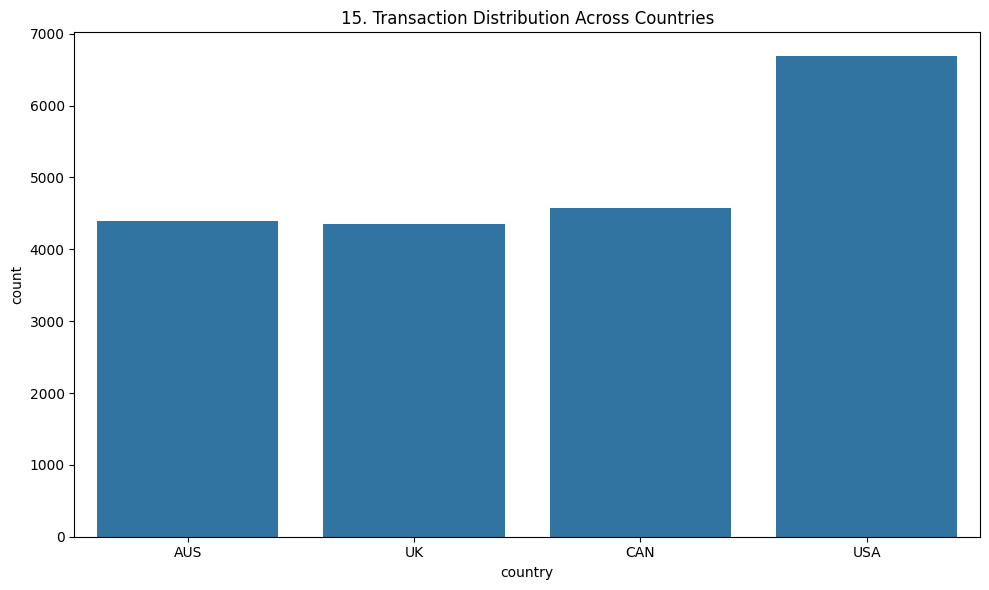

In [34]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='country', data=df)
plt.title(f'{plot_no}. Transaction Distribution Across Countries')
show_fig()
plot_no += 1

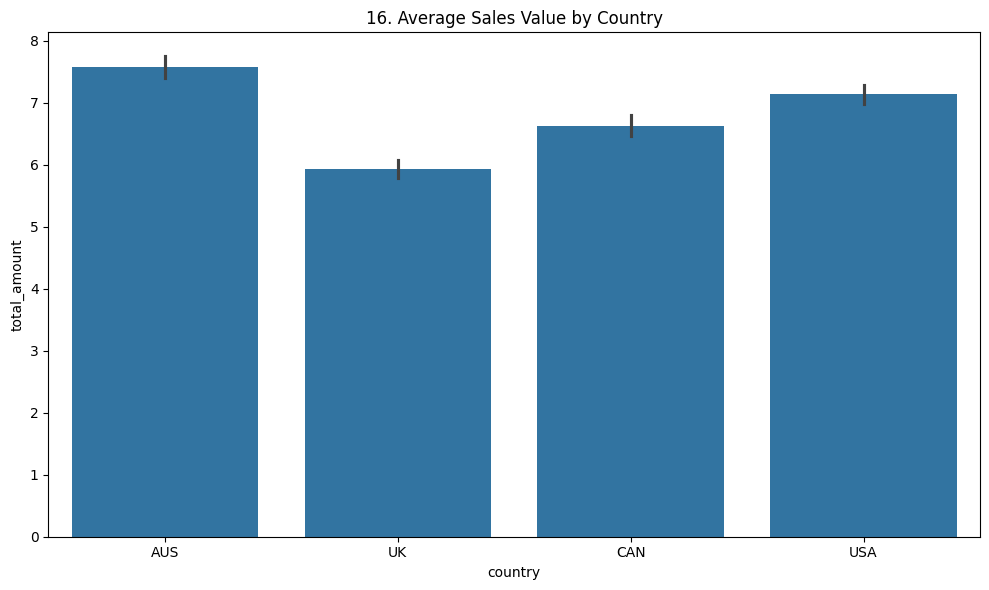

In [35]:
fig = plt.figure(figsize=(10,6))
sns.barplot(x='country', y='total_amount', data=df)
plt.title(f'{plot_no}. Average Sales Value by Country')
show_fig()
plot_no += 1

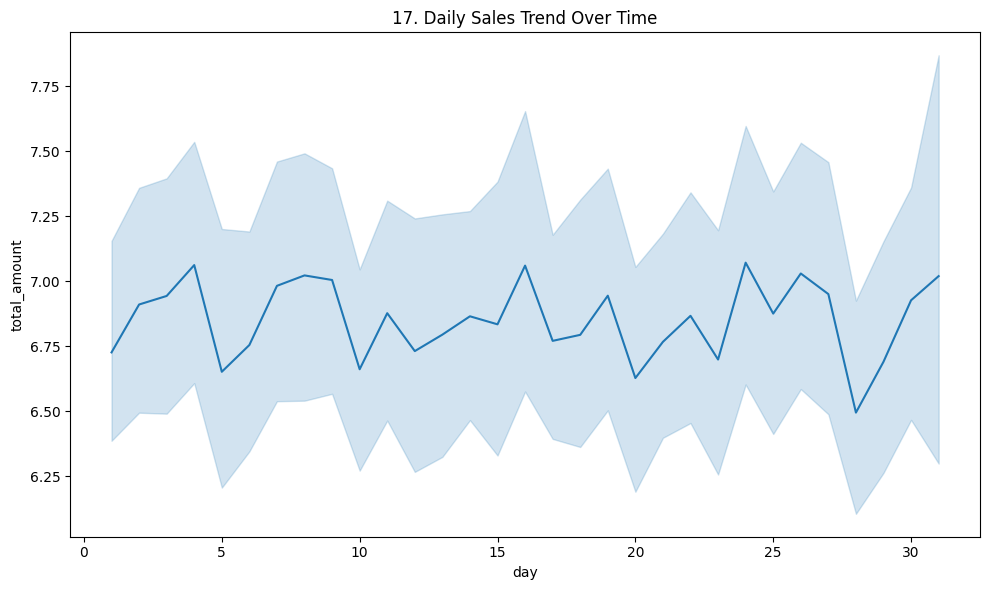

In [36]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='day', y='total_amount', data=df)
plt.title(f'{plot_no}. Daily Sales Trend Over Time')
show_fig()
plot_no += 1

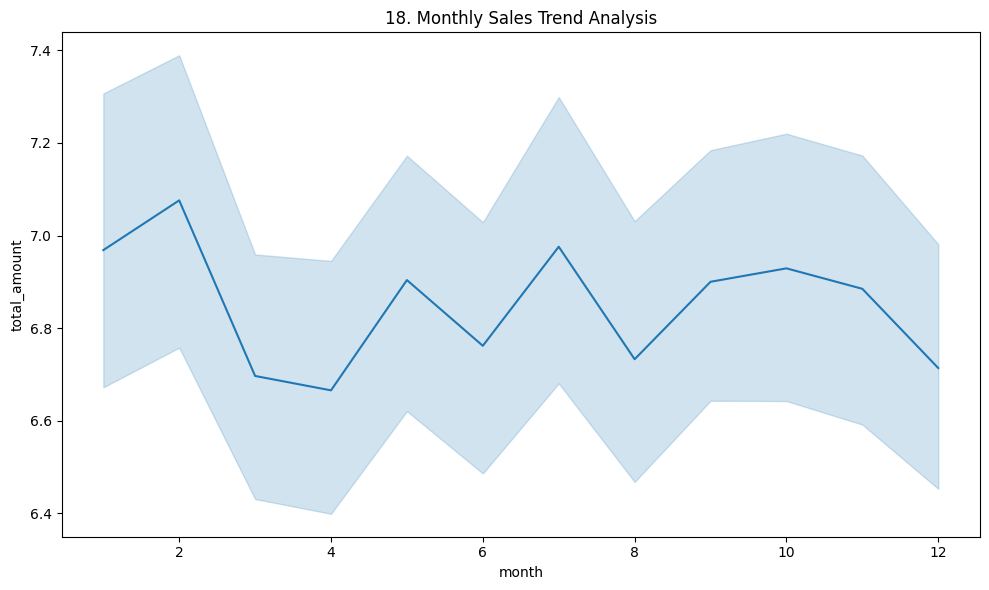

In [37]:
fig = plt.figure(figsize=(10,6))
sns.lineplot(x='month', y='total_amount', data=df)
plt.title(f'{plot_no}. Monthly Sales Trend Analysis')
show_fig()
plot_no += 1

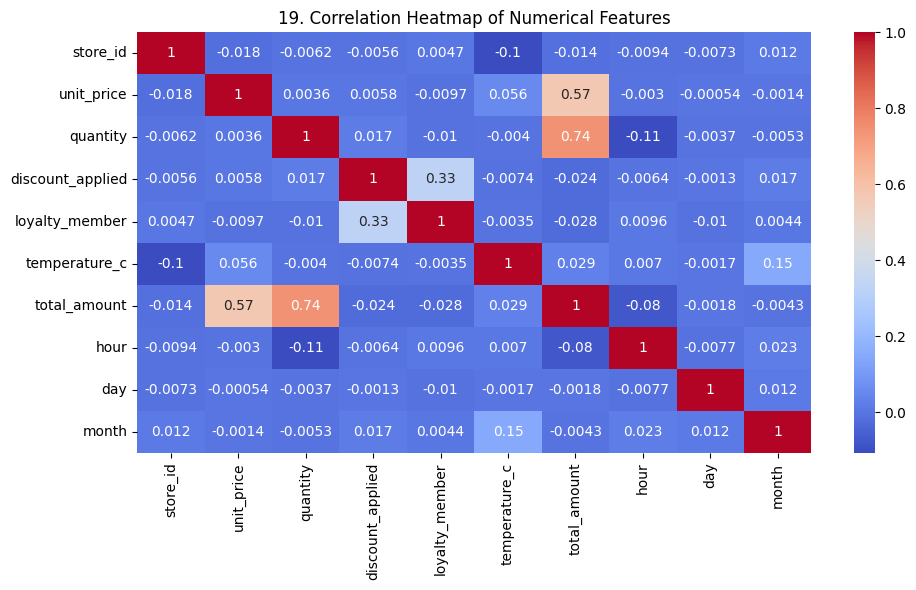

In [38]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Train Model

## convert categorical variables into numeric using one-hot encoding

In [39]:
df_model = pd.get_dummies(df, drop_first=True)

## define features and target variable

In [40]:
X = df_model.drop('total_amount', axis=1)
y = df_model['total_amount']

## split data into training and testing sets

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale the features

In [42]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## initialize and train the Linear Regression model

In [43]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## make predictions

In [44]:
y_pred = model.predict(X_test)

## print model performance

In [45]:
print("R2 Score:", r2_score(y_test, y_pred))

R2 Score: 0.8560568558318341


## plot actual vs predicted values

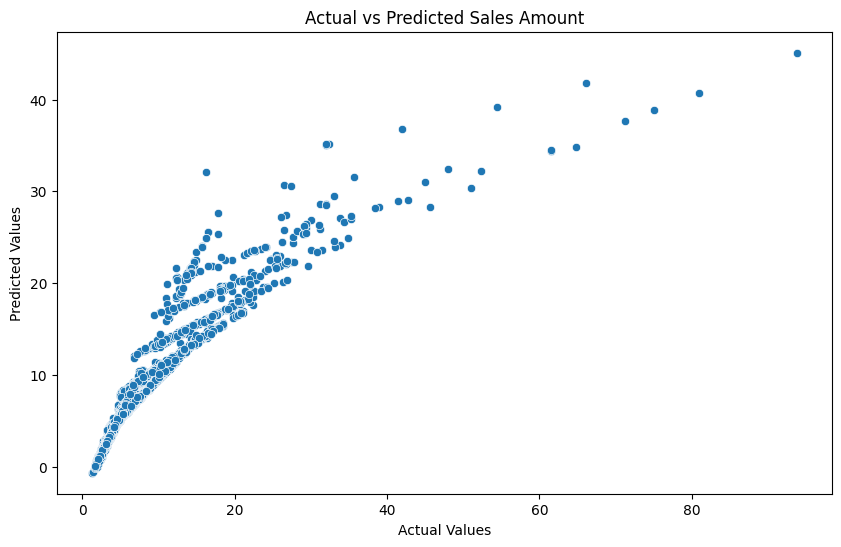

In [46]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Sales Amount")
plt.show()